
# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [45]:
!pip install category_encoders
import pandas as pd
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, recall_score, precision_score, classification_report

In [46]:
from google.colab import files
file = files.upload()

Saving customer_booking.csv to customer_booking (2).csv


In [47]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

In [49]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [50]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)


In [51]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [52]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


In [53]:
print(df['booking_complete'].value_counts())
print(f"\nCompletion rate: {df['booking_complete'].mean()*100:.1f}%")
print(f"\nMissing values are:\n{df.isnull().sum()}")

booking_complete
0    42522
1     7478
Name: count, dtype: int64

Completion rate: 15.0%

Missing values are:
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64


In [54]:
categorical_cols=["sales_channel", "trip_type", "route", "booking_origin"]
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")


sales_channel: 2 unique values

trip_type: 3 unique values

route: 799 unique values

booking_origin: 104 unique values


In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
flight_day,50000.0,3.814420,1.992792,1.00,2.00,4.00,5.00,7.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0


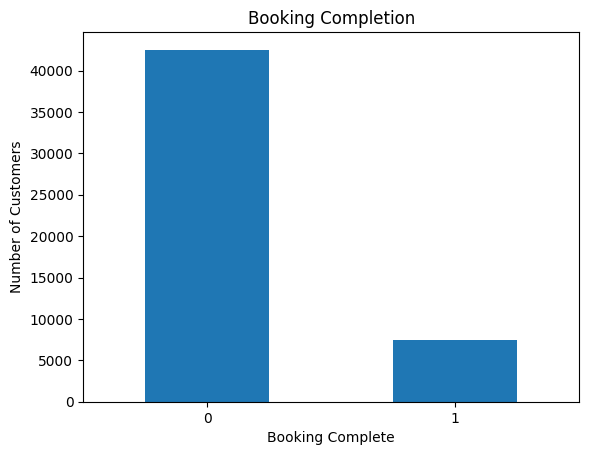

In [56]:
df["booking_complete"].value_counts().plot(kind="bar")

plt.title("Booking Completion")
plt.xlabel("Booking Complete")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [67]:
# Feature 1: Is the flight on a weekend?
df["is_weekend_flight"] = df["flight_day"].isin([6, 7]).astype(int)

# Feature 2: Is the flight in the early morning (before 08:00)?
df['is_early_morning'] = (df['flight_hour'] < 8).astype(int)

# Feature 3: Did the customer book within 30 days of departure?
df['books_within_30_days'] = (df['purchase_lead'] <= 30).astype(int)

# Feature 4: Is the stay longer than 14 nights?
df['long_stay'] = (df['length_of_stay'] > 14).astype(int)

# Feature 5: Total number of extras selected (baggage + seat + meals)
df['total_extras'] = (df['wants_extra_baggage'] +
                      df['wants_preferred_seat'] +
                      df['wants_in_flight_meals'])

print('=== NEW FEATURES SUMMARY ===')
new_features = ['is_weekend_flight','is_early_morning','books_within_30_days','long_stay','total_extras']
for f in new_features:
    print(f'\n{f}:')
    print(df[f].value_counts().sort_index().to_string())

=== NEW FEATURES SUMMARY ===

is_weekend_flight:
is_weekend_flight
0    37634
1    12366

is_early_morning:
is_early_morning
0    29205
1    20795

books_within_30_days:
books_within_30_days
0    32861
1    17139

long_stay:
long_stay
0    24673
1    25327

total_extras:
total_extras
0    10455
1    18216
2    12559
3     8770


In [68]:
features = [
    "is_weekend_flight",
    "is_early_morning",
    "books_within_30_days",
    "long_stay",
    "total_extras"
]

for feature in features:
    print(f"\n--- {feature} ---")
    print(
        df.groupby(feature)["booking_complete"]
          .mean()
          .mul(100)
          .round(2)
    )


--- is_weekend_flight ---
is_weekend_flight
0    15.12
1    14.46
Name: booking_complete, dtype: float64

--- is_early_morning ---
is_early_morning
0    15.26
1    14.53
Name: booking_complete, dtype: float64

--- books_within_30_days ---
books_within_30_days
0    14.18
1    16.45
Name: booking_complete, dtype: float64

--- long_stay ---
long_stay
0    19.17
1    10.85
Name: booking_complete, dtype: float64

--- total_extras ---
total_extras
0    10.67
1    14.96
2    15.97
3    18.60
Name: booking_complete, dtype: float64


In [69]:
df.shape

(50000, 19)

In [70]:
feature_cols = [
    "num_passengers",
    "sales_channel",
    "trip_type",
    "purchase_lead",
    "length_of_stay",
    "flight_hour",
    "flight_day",
    "route",
    "booking_origin",
    "wants_extra_baggage",
    "wants_preferred_seat",
    "wants_in_flight_meals",
    "flight_duration",
    "is_weekend_flight",
    "is_early_morning",
    "books_within_30_days",
    "long_stay",
    "total_extras"
]

X = df[feature_cols]
y = df["booking_complete"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 18)
y shape: (50000,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [72]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40000, 18)
X_test : (10000, 18)
y_train: (40000,)
y_test : (10000,)


In [80]:
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_ohe = onehot.fit_transform(
    X_train[["sales_channel", "trip_type"]]
)

X_test_ohe = onehot.transform(
    X_test[["sales_channel", "trip_type"]]
)

In [81]:
onehot.get_feature_names_out()

array(['sales_channel_Internet', 'sales_channel_Mobile',
       'trip_type_CircleTrip', 'trip_type_OneWay', 'trip_type_RoundTrip'],
      dtype=object)

In [82]:
X_train[['route', 'booking_origin']].head()

,route,booking_origin
11179,HANMEL,Australia
26739,CGKICN,South Korea
16263,KCHPER,Malaysia
8082,DADSYD,Australia
39980,KBVPVG,China


In [83]:
encoder = ce.TargetEncoder(
    cols=['route', 'booking_origin']
)

In [84]:
encoder.fit(X_train, y_train)

TargetEncoder(cols=['route', 'booking_origin'])

In [85]:
X_train_encoded = encoder.transform(X_train)

In [87]:
X_train_encoded.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,is_weekend_flight,is_early_morning,books_within_30_days,long_stay,total_extras
11179,2,Mobile,RoundTrip,168,38,8,2,0.102658,0.050248,0,0,1,8.83,0,0,0,1,1
26739,1,Internet,RoundTrip,54,3,1,6,0.183230,0.106978,0,1,0,6.62,1,1,0,0,1
16263,1,Internet,RoundTrip,221,17,0,7,0.213930,0.341596,1,0,1,5.62,1,1,0,1,2
8082,1,Internet,RoundTrip,59,36,1,3,0.053177,0.050248,0,0,1,8.58,0,1,0,1,1
39980,6,Internet,RoundTrip,49,5,10,5,0.178838,0.204393,1,0,0,5.33,0,0,0,0,1


In [88]:
X_test_encoded = encoder.transform(X_test)

In [89]:
X_test_encoded.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,is_weekend_flight,is_early_morning,books_within_30_days,long_stay,total_extras
15464,1,Internet,RoundTrip,3,61,9,2,0.417178,0.341596,1,0,0,4.75,0,0,1,1,1
21617,1,Internet,RoundTrip,72,19,8,4,0.036713,0.050248,0,0,1,8.83,0,0,0,1,1
2108,2,Internet,RoundTrip,252,19,11,3,0.214552,0.341596,1,0,1,8.83,0,0,0,1,2
588,1,Internet,RoundTrip,162,22,10,4,0.214552,0.044549,1,0,0,8.83,0,0,0,1,1
42278,2,Internet,RoundTrip,120,6,10,3,0.214552,0.341596,1,0,1,8.83,0,0,0,0,2


In [90]:
X_train_final = X_train_encoded.drop(
    columns=["sales_channel", "trip_type"]
).copy()

X_test_final = X_test_encoded.drop(
    columns=["sales_channel", "trip_type"]
).copy()

In [91]:
ohe_columns = onehot.get_feature_names_out()

X_train_ohe_df = pd.DataFrame(
    X_train_ohe,
    columns=ohe_columns,
    index=X_train.index
)

X_test_ohe_df = pd.DataFrame(
    X_test_ohe,
    columns=ohe_columns,
    index=X_test.index
)

In [92]:
X_train_final = pd.concat(
    [X_train_final, X_train_ohe_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_final, X_test_ohe_df],
    axis=1
)

In [93]:
print(X_train_final.shape)
print(X_test_final.shape)

(40000, 21)
(10000, 21)


In [94]:
X_train_final.dtypes

,0
num_passengers,int64
purchase_lead,int64
length_of_stay,int64
flight_hour,int64
flight_day,int64
route,float64
booking_origin,float64
wants_extra_baggage,int64
wants_preferred_seat,int64
wants_in_flight_meals,int64


In [96]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [97]:
rf_model.fit(X_train_final, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [99]:
y_pred = rf_model.predict(X_test_final)
y_pred_proba = rf_model.predict_proba(X_test_final)[:, 1]

In [100]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      8504
           1       0.56      0.16      0.25      1496

    accuracy                           0.86     10000
   macro avg       0.71      0.57      0.59     10000
weighted avg       0.82      0.86      0.82     10000



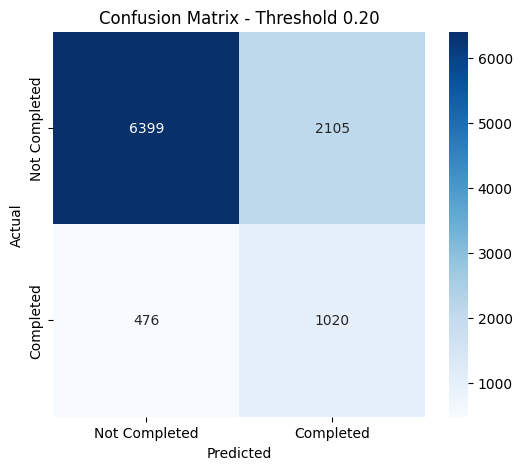

In [101]:
# Predictions using threshold 0.20
y_pred_020 = (y_pred_proba >= 0.20).astype(int)

cm = confusion_matrix(y_test, y_pred_020)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Completed", "Completed"],
    yticklabels=["Not Completed", "Completed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Threshold 0.20")

plt.show()

In [102]:
cm = confusion_matrix(y_test, y_pred)

cm_table = pd.DataFrame(
    cm,
    index=["Actual 0 (Not Completed)", "Actual 1 (Completed)"],
    columns=["Predicted 0 (Not Completed)", "Predicted 1 (Completed)"]
)

cm_table

,Predicted 0 (Not Completed),Predicted 1 (Completed)
Actual 0 (Not Completed),8315,189
Actual 1 (Completed),1255,241


In [103]:
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1]:

    pred = (y_pred_proba >= threshold).astype(int)

    print(
        f"Threshold: {threshold}",
        f"| Precision: {precision_score(y_test, pred):.3f}",
        f"| Recall: {recall_score(y_test, pred):.3f}"
    )

Threshold: 0.5 | Precision: 0.552 | Recall: 0.164
Threshold: 0.4 | Precision: 0.455 | Recall: 0.296
Threshold: 0.3 | Precision: 0.386 | Recall: 0.482
Threshold: 0.2 | Precision: 0.326 | Recall: 0.682
Threshold: 0.1 | Precision: 0.258 | Recall: 0.856


In [104]:
y_pred_20 = (y_pred_proba >= 0.20).astype(int)

cm_20 = confusion_matrix(y_test, y_pred_20)

cm_20_table = pd.DataFrame(
    cm_20,
    index=["Actual 0 (Not Completed)", "Actual 1 (Completed)"],
    columns=["Predicted 0 (Not Completed)", "Predicted 1 (Completed)"]
)

cm_20_table

,Predicted 0 (Not Completed),Predicted 1 (Completed)
Actual 0 (Not Completed),6399,2105
Actual 1 (Completed),476,1020


In [105]:
auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.7898


In [108]:
targeted_customers = (y_pred_proba >= 0.20).sum()

actual_buyers_targeted = (
    ((y_pred_proba >= 0.20) & (y_test == 1))
).sum()

false_positives = (
    ((y_pred_proba >= 0.20) & (y_test == 0))
).sum()

print("Customers targeted:", targeted_customers)
print("Actual buyers found:", actual_buyers_targeted)
print("Non-buyers targeted:", false_positives)

Customers targeted: 3125
Actual buyers found: 1020
Non-buyers targeted: 2105


In [114]:
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,route,0.190344
1,purchase_lead,0.163370
3,flight_hour,0.117632
2,length_of_stay,0.106024
6,booking_origin,0.103524
4,flight_day,0.075454
10,flight_duration,0.068527
0,num_passengers,0.045776
15,total_extras,0.024269
12,is_early_morning,0.016834


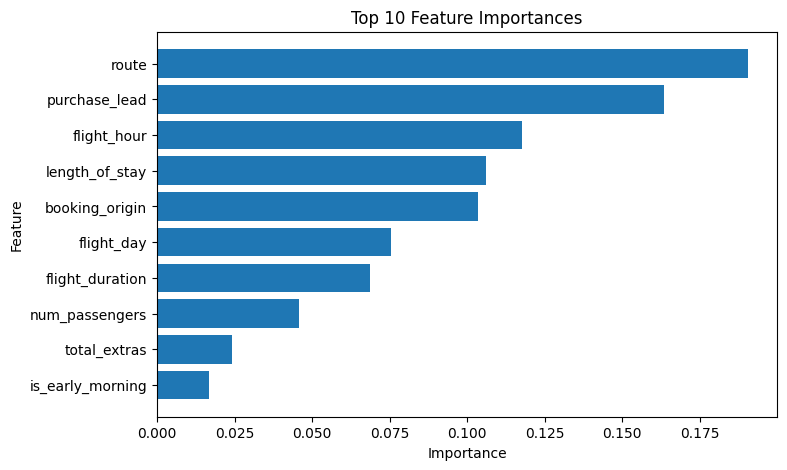

In [115]:
# Take top 10 features
top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")

plt.show()

In [116]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train_final, y_train), 1
):

    X_fold_train = X_train_final.iloc[train_idx]
    X_fold_val = X_train_final.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Train model
    rf_cv = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    rf_cv.fit(X_fold_train, y_fold_train)

    # Probability predictions
    prob = rf_cv.predict_proba(X_fold_val)[:, 1]

    # Threshold = 0.20
    pred = (prob >= 0.20).astype(int)

    # Metrics
    auc = roc_auc_score(y_fold_val, prob)
    recall = recall_score(y_fold_val, pred)

    fold_results.append([
        fold,
        auc,
        recall
    ])

fold_results

[[1, np.float64(0.7985406356481235), 0.6889632107023411],
 [2, np.float64(0.786724905082393), 0.6688963210702341],
 [3, np.float64(0.7984085325570833), 0.6981605351170569],
 [4, np.float64(0.7952350620291235), 0.6791979949874687],
 [5, np.float64(0.797019067832254), 0.697577276524645]]

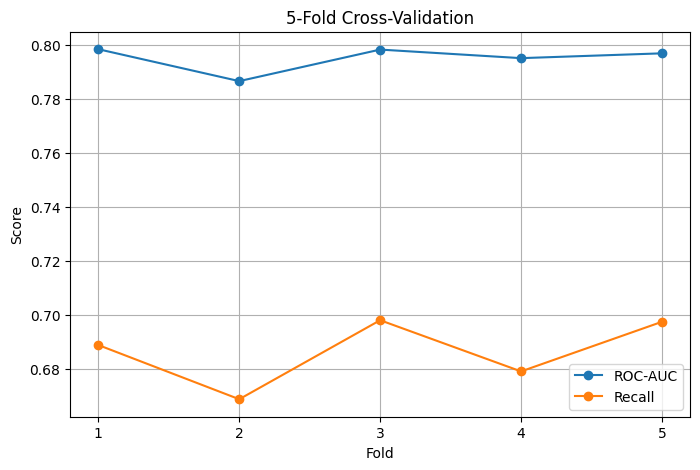

In [117]:
fold_results_df = pd.DataFrame(
    fold_results,
    columns=["Fold", "ROC-AUC", "Recall"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    fold_results_df["Fold"],
    fold_results_df["ROC-AUC"],
    marker="o",
    label="ROC-AUC"
)

plt.plot(
    fold_results_df["Fold"],
    fold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("5-Fold Cross-Validation")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True)

plt.show()

In [118]:
fold_results_df = pd.DataFrame(
    fold_results,
    columns=["Fold", "ROC-AUC", "Recall"]
)

fold_results_df

,Fold,ROC-AUC,Recall
0,1,0.798541,0.688963
1,2,0.786725,0.668896
2,3,0.798409,0.698161
3,4,0.795235,0.679198
4,5,0.797019,0.697577


In [122]:
print("Mean ROC-AUC:", fold_results_df["ROC-AUC"].mean()*100)
print("Mean Recall:", fold_results_df["Recall"].mean()*100)

Mean ROC-AUC: 79.51856406297955
Mean Recall: 68.65590676803491
